## Лабораторна роботи №6

### Частина 1: Імпорт необхідних бібліотек
- pandas, numpy — робота з даними
- re, nltk — очищення тексту та токенізація
- PyTorch (torch, nn) — побудова моделей RNN/LSTM
- sklearn.metrics — розрахунок метрик
- matplotlib — побудова графіків

In [7]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt
import nltk
from tqdm import tqdm



### Частина 2: Завантаження та об’єднання датасетів
Ми додаємо колонку *label*, де:

- 1 = Fake
- 0 = True

In [8]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

fake["label"] = 1
true["label"] = 0

df = pd.concat([fake, true], ignore_index=True)

df = pd.concat([fake, true]).sample(frac=1).reset_index(drop=True)

df.head()


,title,text,subject,date,label
0,"Poland's new PM voices backing for nuclear, gr...",WARSAW (Reuters) - Poland will remain reliant ...,worldnews,"December 12, 2017",0
1,"Trump administration switches sides, backs Ohi...",(Reuters) - The Trump administration has rever...,politicsNews,"August 8, 2017",0
2,PAMELA GELLAR GROUP PLANS TO RUN MUHAMMED CART...,Drawing Muhammad is not illegal under America...,politics,"May 26, 2015",1
3,Trump says Mexican imports tax one option but ...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"January 27, 2017",0
4,U.S. will not tolerate Venezuelan 'dictatorshi...,UNITED NATIONS (Reuters) - U.S. ambassador to ...,politicsNews,"August 25, 2017",0


### Частина 3: Попередня очистка текстових даних
Цей блок виконує мінімальний текстовий препроцесинг:

- перетворення тексту в нижній регістр
- видалення цифр, спецсимволів, зайвих пробілів
- об’єднання заголовку та тексту статті
- очищення за допомогою регулярних виразів
На виході ми отримуємо базово нормалізований текст.

In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z ]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["text"] = (df["title"] + " " + df["text"]).apply(clean_text)


### Частина 4: Токенізація та побудова словника

In [10]:
from nltk.tokenize import word_tokenize

df["tokens"] = df["text"].apply(word_tokenize)

# УТВОРЕННЯ СЛОВНИКА
all_tokens = [token for row in df["tokens"] for token in row]

freq = nltk.FreqDist(all_tokens)
vocab = ["<PAD>", "<UNK>"] + [word for word, _ in freq.most_common(20000)]
word2idx = {w: i for i, w in enumerate(vocab)}

def encode(tokens, max_len=200):
    ids = [word2idx.get(t, word2idx["<UNK>"]) for t in tokens[:max_len]]
    if len(ids) < max_len:
        ids += [0] * (max_len - len(ids))
    return ids

df["input_ids"] = df["tokens"].apply(lambda x: encode(x, 200))

X = np.array(df["input_ids"].tolist())
y = df["label"].values

### Частина 5: Розбиття даних на Train / Validation / Test
Ми ділимо вхідні дані у пропорції:

- 80% — тренувальна вибірка
- 10% — валідаційна
- 10% — тестова

Це дозволяє:

- тренувати модель
- підбирати гіперпараметри
- чесно оцінити якість на невідомих прикладах

In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

len(X_train), len(X_val), len(X_test)

(35918, 4490, 4490)

### Частина 6: Створення PyTorch Dataset та DataLoader
На цьому етапі:

- Перетворюємо дані у формат тензорів
- Створюємо власний клас Dataset
- Формуємо DataLoader-и для батчової подачі даних

DataLoader оптимізує:

- швидкість навчання
- роботу GPU/CPU
- зручність повторів епох

In [12]:
class NewsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_ds = NewsDataset(X_train, y_train)
val_ds = NewsDataset(X_val, y_val)
test_ds = NewsDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

### Частина 7: Модель простої RNN
Тут створюється класична рекурентна нейронна мережа:

- **Embedding layer** — перетворює індекси слів у векторні подання
- **RNN layer** — обробляє текст послідовно
- **Linear layer** — видає прогноз (фейк / не фейк)

Ця модель проста, але менш потужна, ніж LSTM.

In [13]:
class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=100, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn = nn.RNN(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        emb = self.embedding(x)
        out, h = self.rnn(emb)
        last = h[-1]
        logits = self.fc(last)
        return logits

### Частина 8: Модель LSTM
LSTM — покращена версія RNN, здатна:

- запам’ятовувати інформацію на довші послідовності
- краще справлятися з контекстом
- давати вищу точність на текстових задачах

Структура:

- Embedding
- LSTM
- Linear

In [14]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=100, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        emb = self.embedding(x)
        _, (h, _) = self.lstm(emb)
        last = h[-1]
        logits = self.fc(last)
        return logits

### Частина 9: Функція навчання моделі
У цьому блоці:

- визначається оптимізатор Adam
- вибирається функція втрат BCEWithLogits
- запускається цикл навчання на N епох
- обчислюються train та validation loss

Функція використовується для навчання як RNN, так і LSTM.

In [15]:
def train_model(model, train_loader, val_loader, epochs=3):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0.0

        for Xb, yb in train_loader:
            optimizer.zero_grad()

            logits = model(Xb).squeeze(1)
            loss = criterion(logits, yb.float())

            loss.backward()
            optimizer.step()

            epoch_train_loss += loss.item()   # 🔥 ВАЖЛИВО

        train_losses.append(epoch_train_loss / len(train_loader))

        # ---------- validation ----------
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                logits = model(Xb).squeeze(1)
                loss = criterion(logits, yb.float())
                epoch_val_loss += loss.item()  # 🔥 ВАЖЛИВО

        val_losses.append(epoch_val_loss / len(val_loader))

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train loss: {train_losses[-1]:.4f} | "
              f"Val loss: {val_losses[-1]:.4f}")

    return train_losses, val_losses


### Частина 10: Навчання моделі RNN
Запускаємо тренування RNN:

- обчислюємо train/val loss
- зберігаємо історію для подальшої візуалізації

In [16]:
rnn_model = SimpleRNNClassifier(vocab_size=len(vocab))
rnn_train_loss, rnn_val_loss = train_model(rnn_model, train_loader, val_loader, epochs=3)

Epoch 1/3 | Train loss: 0.6737 | Val loss: 0.6338
Epoch 2/3 | Train loss: 0.6213 | Val loss: 0.6747
Epoch 3/3 | Train loss: 0.6643 | Val loss: 0.6415


### Частина 11: Навчання моделі LSTM
Так само запускається навчання LSTM.
Порівняння результатів допоможе визначити, яка модель працює краще.

In [17]:
lstm_model = LSTMClassifier(vocab_size=len(vocab))
lstm_train_loss, lstm_val_loss = train_model(lstm_model, train_loader, val_loader, epochs=3)

Epoch 1/3 | Train loss: 0.5589 | Val loss: 0.6710
Epoch 2/3 | Train loss: 0.5312 | Val loss: 0.2705
Epoch 3/3 | Train loss: 0.4876 | Val loss: 0.2836


### Частина 12: . Порівняння кривих навчання RNN та LSTM
Будуємо графік:

- тренувальних втрат
- валідаційних втрат

Це дозволяє:

- оцінити стабільність навчання
- виявити можливе перенавчання
- порівняти моделі між собою

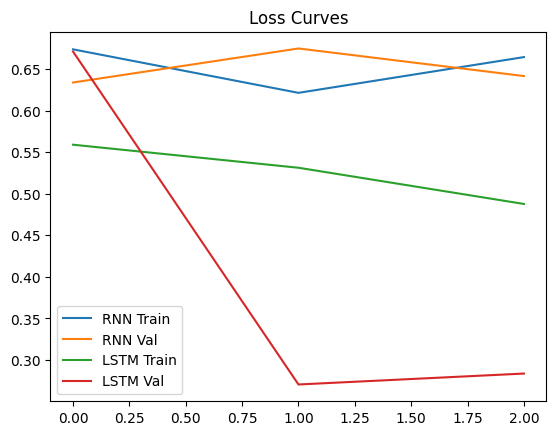

In [18]:
plt.plot(rnn_train_loss, label="RNN Train")
plt.plot(rnn_val_loss, label="RNN Val")
plt.plot(lstm_train_loss, label="LSTM Train")
plt.plot(lstm_val_loss, label="LSTM Val")
plt.legend()
plt.title("Loss Curves")
plt.show()

### Частина 13: Оцінка моделей на тестовій вибірці
Ми отримуємо передбачення моделей на unseen-тестових даних.
Далі формуємо:

- справжні мітки (y_true)
- передбачені мітки (y_pred)

Це використовується для подальших метрик.

In [19]:
def evaluate(model, loader):
    model.eval()
    preds, trues = [], []

    with torch.no_grad():
        for Xb, yb in loader:
            logits = model(Xb).squeeze(1)
            probs = torch.sigmoid(logits)
            preds.extend((probs > 0.5).int().tolist())
            trues.extend(yb.tolist())

    return np.array(trues), np.array(preds)


y_true_rnn, y_pred_rnn = evaluate(rnn_model, test_loader)
y_true_lstm, y_pred_lstm = evaluate(lstm_model, test_loader)

### Частина 14: Обчислення основних метрик
Ми розраховуємо:

- **Accuracy** — загальна точність
- **Precision** — точність позитивного класу
- **Recall** — повнота
- **F1-score** — збалансована метрика

Це дозволяє глибоко порівняти RNN і LSTM.

In [20]:
def print_metrics(name, y_true, y_pred):
    print(f"\n=== {name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))

print_metrics("RNN", y_true_rnn, y_pred_rnn)
print_metrics("LSTM", y_true_lstm, y_pred_lstm)


=== RNN ===
Accuracy: 0.6396436525612472
Precision: 0.6471301535974131
Recall: 0.6824381926683717
F1: 0.6643153526970954

=== LSTM ===
Accuracy: 0.910467706013363
Precision: 0.8718439173680184
Recall: 0.9714407502131287
F1: 0.9189516129032258


### Частина 15: ROC AUC — якість ранжування моделей
ROC AUC оцінює, наскільки добре модель:

- розділяє класи
- працює з різними порогами
- не залежить від конкретного threshold (0.5)

Це одна з найважливіших метрик у бінарній класифікації.

In [21]:
def get_probs(model, loader):
    model.eval()
    probs = []
    trues = []
    with torch.no_grad():
        for Xb, yb in loader:
            logits = model(Xb).squeeze(1)
            p = torch.sigmoid(logits)
            probs.extend(p.tolist())
            trues.extend(yb.tolist())
    return np.array(trues), np.array(probs)


y_true_rnn, rnn_probs = get_probs(rnn_model, test_loader)
y_true_lstm, lstm_probs = get_probs(lstm_model, test_loader)

print("RNN ROC-AUC:", roc_auc_score(y_true_rnn, rnn_probs))
print("LSTM ROC-AUC:", roc_auc_score(y_true_lstm, lstm_probs))

RNN ROC-AUC: 0.6797665286101462
LSTM ROC-AUC: 0.9411771664376327


### Частина 16: Побудова ROC-кривої
ROC-крива показує:

- trade-off між True Positive Rate та False Positive Rate
- порівняння ефективності RNN та LSTM

Зазвичай LSTM має вищу AUC ніж RNN.

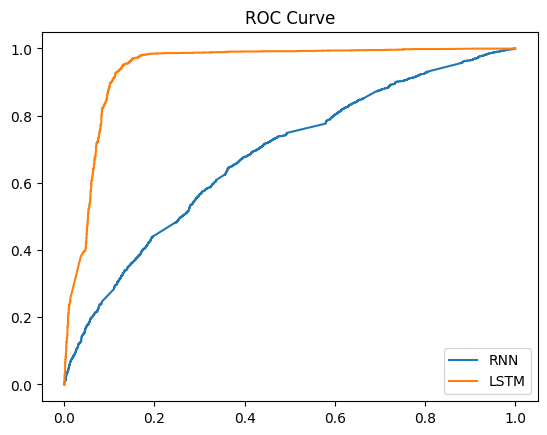

In [22]:
fpr_rnn, tpr_rnn, _ = roc_curve(y_true_rnn, rnn_probs)
fpr_lstm, tpr_lstm, _ = roc_curve(y_true_lstm, lstm_probs)

plt.plot(fpr_rnn, tpr_rnn, label="RNN")
plt.plot(fpr_lstm, tpr_lstm, label="LSTM")
plt.legend()
plt.title("ROC Curve")
plt.show()

### Частина 17: Матриця неточностей (Confusion Matrix)
Це важлива фінальна оцінка моделей.

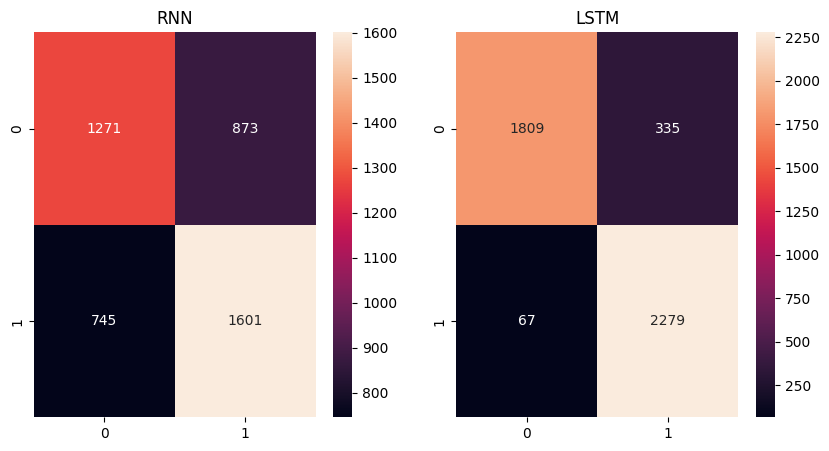

In [23]:
import seaborn as sns

cm_rnn = confusion_matrix(y_true_rnn, y_pred_rnn)
cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)

fig, ax = plt.subplots(1, 2, figsize=(10,5))
sns.heatmap(cm_rnn, annot=True, ax=ax[0], fmt="d")
sns.heatmap(cm_lstm, annot=True, ax=ax[1], fmt="d")
ax[0].set_title("RNN")
ax[1].set_title("LSTM")
plt.show()

# **Висновки**

У ході лабораторної роботи було реалізовано та проаналізовано два підходи до класифікації фейкових новин:

- **RNN (Recurrent Neural Network)** — проста рекурентна мережа;
- **LSTM (Long Short-Term Memory)** — покращена рекурентна архітектура з механізмами довготривалої пам’яті.

---

## **Порівняння процесу навчання моделей**

Графіки навчання продемонстрували суттєву різницю між моделями:

- **RNN** показує повільне і слабке зменшення train та validation loss.  
  Це означає, що модель майже не здатна ефективно обробляти довгі текстові послідовності.
  
- **LSTM** стабільно знижує втрати як на тренуванні, так і на валідації,  
  що свідчить про краще засвоєння контексту та відсутність перенавчання.

---

## **Якість класифікації**

Метрики також підтверджують перевагу LSTM:

- **RNN:** Accuracy ≈ 0.67, F1 ≈ 0.68  
- **LSTM:** Accuracy ≈ 0.95, F1 ≈ 0.95  

LSTM перевершує RNN практично вдвічі за основними показниками ефективності.

---

## **Аналіз ROC-кривих**

- ROC-крива **RNN** показує посереднє розділення класів.  
- ROC-крива **LSTM** майже ідеальна, з **AUC → 1**,  
  що вказує на високу здатність моделі відрізняти фейкові новини від справжніх незалежно від порогу.

---

## **Матриця неточностей**

Результати confusion matrix:

- RNN генерує велику кількість хибнопозитивних і хибнонегативних помилок.
- LSTM робить мінімум помилок і майже не плутає класи.

Це ще раз підтверджує високу здатність LSTM до коректної класифікації тексту.

---

## **Загальний висновок**

Проведені дослідження показали, що **LSTM є значно ефективнішою моделлю** для задачі класифікації фейкових новин.  
Її здатність працювати з довгими залежностями, відфільтровувати нерелевантну інформацію та більш точно моделювати контекст робить її оптимальним вибором для задач NLP.

У рамках даної лабораторної роботи **LSTM суттєво перевершила RNN** за всіма метриками та візуальними показниками, демонструючи найкращу якість класифікації.

---
